In [22]:
import pandas as pd #import pandas library
df = pd.read_csv("/content/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [23]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (8807, 12)


In [24]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [25]:
# Display data types
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [26]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [27]:
# Calculate percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.round(2)

,0
show_id,0.00
type,0.00
title,0.00
director,29.91
cast,9.37
country,9.44
date_added,0.11
release_year,0.00
rating,0.05
duration,0.03


In [28]:
# Fill missing value
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Not Available")
df["country"] = df["country"].fillna(df["country"].mode()[0])
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

In [29]:
# Verify that missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [30]:
# Check  null values
print("Does the dataset contain any null values?")
print(df.isnull().values.any())

Does the dataset contain any null values?
False


In [31]:
# Count duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [32]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [34]:
# Check duplicates again
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [35]:
#convert the date format
df["date_added"] = df["date_added"].str.strip()

df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

In [36]:
df["date_added"].isnull().sum()

np.int64(0)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [38]:
# Save the cleaned dataset
df.to_csv("cleaned_netflix_titles.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
#UNIVARIATE ANALYSIS


In [66]:

# Tabular Format: Distribution of Content Types

type_table = (
    df["type"]
    .value_counts()
    .reset_index()
)

type_table.columns = ["Content Type", "Count"]

type_table

,Content Type,Count
0,Movie,6131
1,TV Show,2676


/tmp/ipykernel_645/1915648540.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


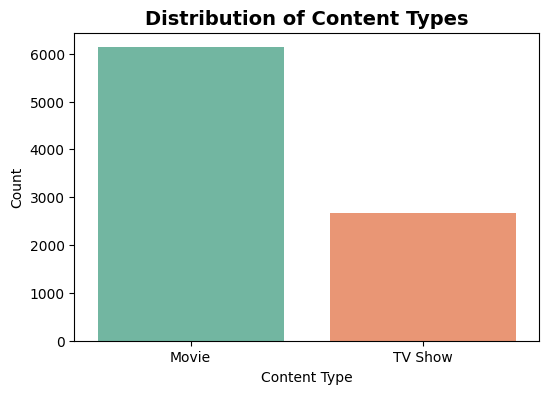

In [51]:
#Count Plot -Count Plot of Year Added most shows by netflix
plt.figure(figsize=(6,4))
sns.countplot(
    x="type",
    data=df,
    palette="Set2"
)
plt.title("Distribution of Content Types", fontsize=14, fontweight="bold")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

In [67]:
# Tabular Format: Top 10 Content Ratings

rating_table = (
    df["rating"]
    .value_counts()
    .head(10)
    .reset_index()
)

rating_table.columns = ["Rating", "Count"]

rating_table

,Rating,Count
0,TV-MA,3211
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,80


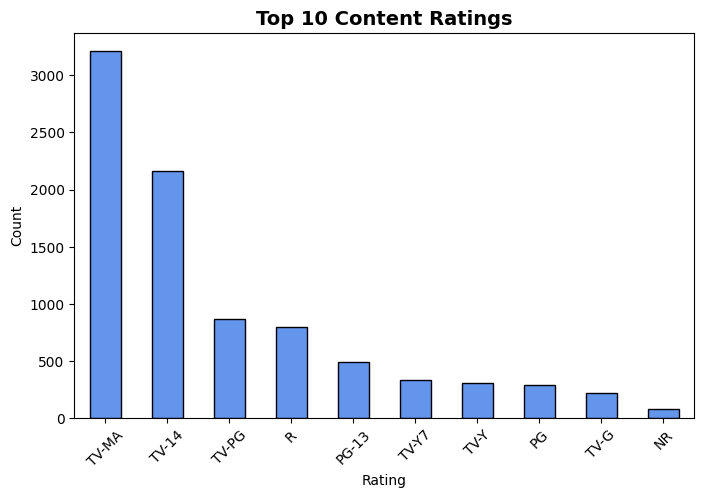

In [40]:
#Bar Chart – Top Content Ratings

plt.figure(figsize=(8,5))
df["rating"].value_counts().head(10).plot(
    kind="bar",
    color="cornflowerblue",
    edgecolor="black"
)
plt.title("Top 10 Content Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [68]:
# Tabular Format: Release Year Distribution

release_year_table = (
    df["release_year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

release_year_table.columns = ["Release Year", "Number of Titles"]

release_year_table

,Release Year,Number of Titles
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4
...,...,...
69,2017,1032
70,2018,1147
71,2019,1030
72,2020,953


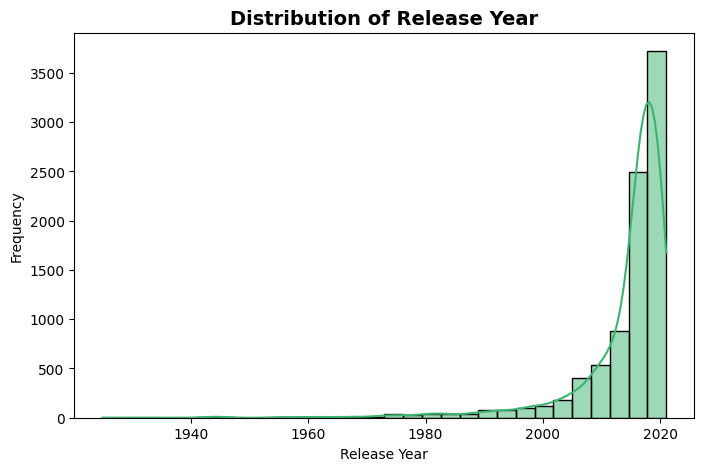

In [42]:
#HISTOGRAM-Distribution of the release year
plt.figure(figsize=(8,5))
sns.histplot(
    df["release_year"],
    bins=30,
    kde=True,
    color="mediumseagreen"
)
plt.title("Distribution of Release Year", fontsize=14, fontweight="bold")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()


In [69]:
# Tabular Format: Movie Duration Distribution

duration_table = (
    movies["duration"]
    .value_counts()
    .sort_index()
    .reset_index()
)

duration_table.columns = ["Duration (Minutes)", "Number of Movies"]

duration_table

,Duration (Minutes),Number of Movies
0,1,3
1,3,1
2,5,1
3,8,1
4,9,1
...,...,...
201,233,1
202,237,1
203,253,1
204,273,1


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_645/2661689887.py:3: SyntaxWarning: invalid escape sequence '\d'
  movies["duration"] = movies["duration"].str.extract("(\d+)").astype(int)


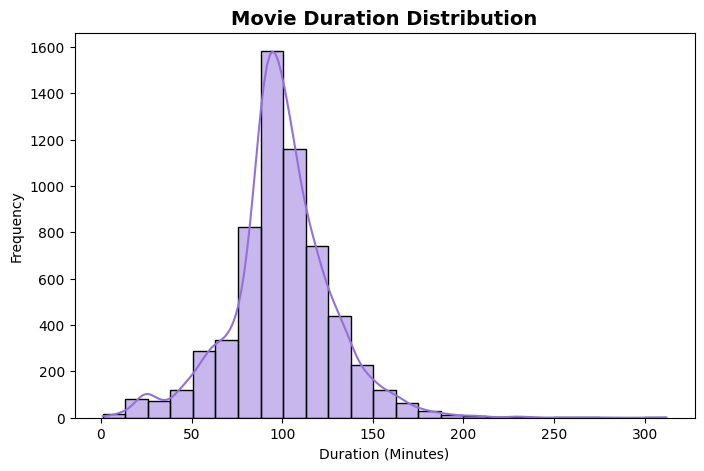

In [43]:
#Histogram – Movie Duration
movies = df[df["type"]=="Movie"].copy()
movies["duration"] = movies["duration"].str.extract("(\d+)").astype(int)
plt.figure(figsize=(8,5))
sns.histplot(
    movies["duration"],
    bins=25,
    kde=True,
    color="mediumpurple"
)
plt.title("Movie Duration Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")
plt.show()

In [70]:
# Tabular Format: Movie Duration Summary

duration_summary = (
    movies["duration"]
    .describe()
    .reset_index()
)

duration_summary.columns = ["Statistic", "Value"]

duration_summary

,Statistic,Value
0,count,6131.000000
1,mean,99.528951
2,std,28.367576
3,min,1.000000
4,25%,87.000000
5,50%,98.000000
6,75%,114.000000
7,max,312.000000


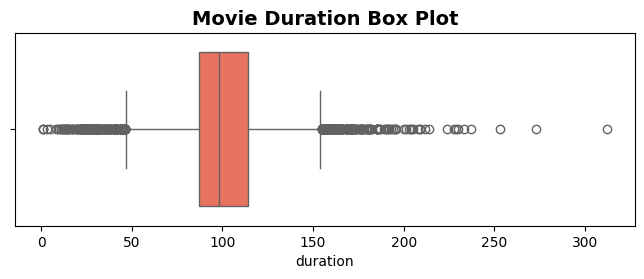

In [44]:
#BOX PLOT- Movie duration
plt.figure(figsize=(8,2.5))
sns.boxplot(
    x=movies["duration"],
    color="tomato"
)
plt.title("Movie Duration Box Plot", fontsize=14, fontweight="bold")
plt.show()

In [71]:
# Tabular Format: Top 10 Producing Countries

country_table = (
    country
    .reset_index()
)

country_table.columns = ["Country", "Number of Titles"]

country_table

,Country,Number of Titles
0,United States,4520
1,India,1046
2,United Kingdom,804
3,Canada,445
4,France,393
5,Japan,318
6,Spain,232
7,South Korea,231
8,Germany,226
9,Mexico,169


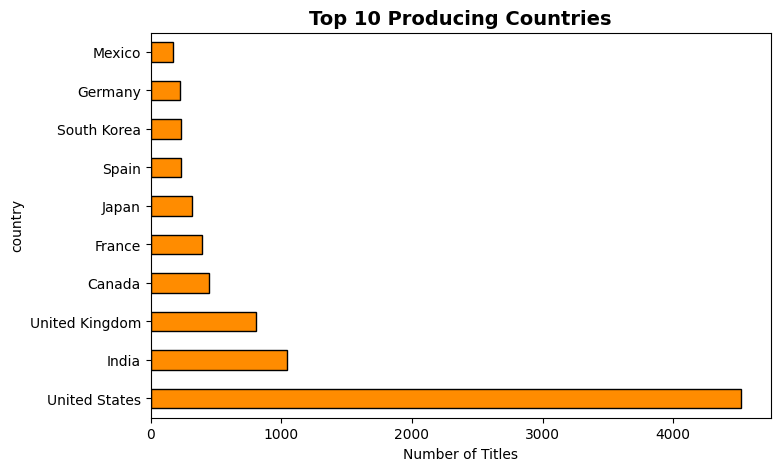

In [45]:
#HORIZONTAL BAR CHART -TOP COUNTRIES
country = df["country"].str.split(", ").explode().value_counts().head(10)

plt.figure(figsize=(8,5))

country.plot(
    kind="barh",
    color="darkorange",
    edgecolor="black"
)

plt.title("Top 10 Producing Countries", fontsize=14, fontweight="bold")
plt.xlabel("Number of Titles")
plt.show()

In [72]:
# Tabular Format: Top 10 Genres

genre_table = (
    genre
    .reset_index()
)

genre_table.columns = ["Genre", "Number of Titles"]

genre_table

,Genre,Number of Titles
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


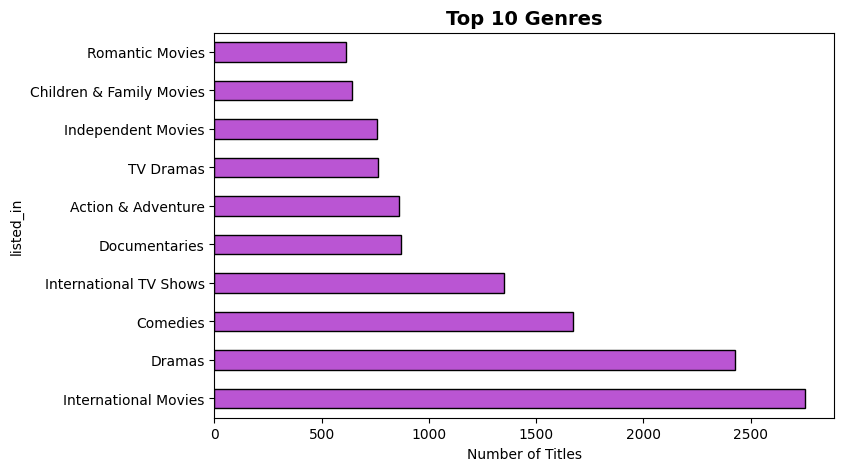

In [46]:
#Horizontal Bar Chart – Top Genres
genre = df["listed_in"].str.split(", ").explode().value_counts().head(10)

plt.figure(figsize=(8,5))

genre.plot(
    kind="barh",
    color="mediumorchid",
    edgecolor="black"
)

plt.title("Top 10 Genres", fontsize=14, fontweight="bold")
plt.xlabel("Number of Titles")
plt.show()

In [73]:
# Tabular Format: Movies vs TV Shows

pie_table = (
    df["type"]
    .value_counts()
    .reset_index()
)

pie_table.columns = ["Content Type", "Count"]

pie_table["Percentage (%)"] = (
    pie_table["Count"] /
    pie_table["Count"].sum() * 100
).round(2)

pie_table

,Content Type,Count,Percentage (%)
0,Movie,6131,69.62
1,TV Show,2676,30.38


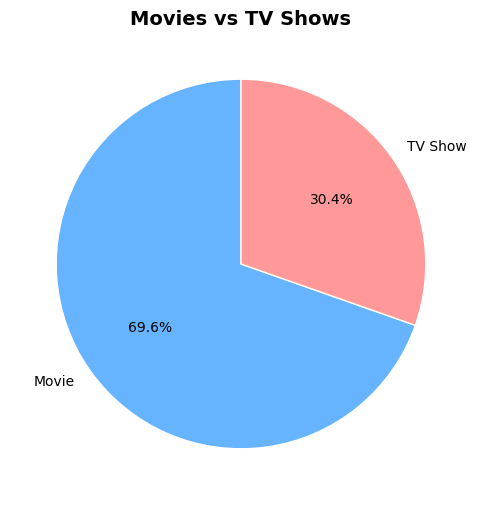

In [47]:
#Pie Chart – Movies vs TV Shows
plt.figure(figsize=(6,6))

colors = ["#66b3ff", "#ff9999"]

df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor":"white"}
)
plt.title("Movies vs TV Shows", fontsize=14, fontweight="bold")
plt.ylabel("")
plt.show()

In [ ]:
#BIVARIATE ANALYSIS

In [52]:
# Prepare movie duration data
movies = df[df["type"]=="Movie"].copy()
movies["duration"] = movies["duration"].str.extract("(\d+)").astype(int)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_645/1544147193.py:3: SyntaxWarning: invalid escape sequence '\d'
  movies["duration"] = movies["duration"].str.extract("(\d+)").astype(int)


In [74]:
# Tabular Format: Release Year vs Movie Duration

scatter_table = (
    movies[
        ["release_year", "duration", "rating"]
    ]
    .sort_values("release_year")
)

scatter_table.head(20)

,release_year,duration,rating
7790,1942,52,TV-14
8205,1942,18,TV-14
8660,1943,61,TV-PG
8739,1943,82,TV-PG
8763,1943,45,TV-PG
8419,1944,40,TV-PG
8436,1944,40,TV-14
8640,1944,76,TV-14
7575,1945,59,TV-MA
7219,1945,63,TV-14


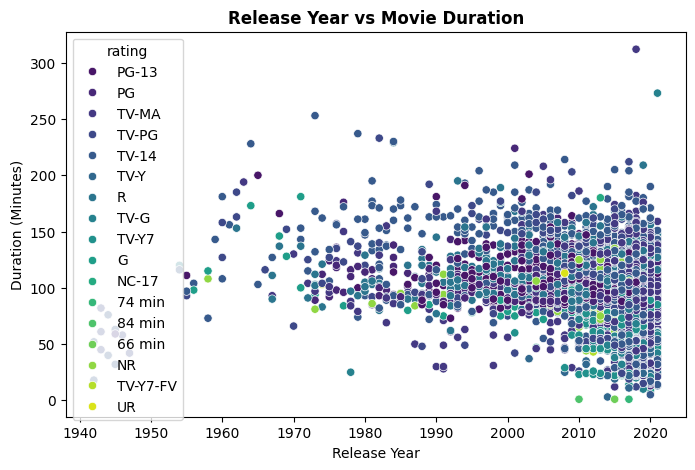

In [53]:
# Scatter Plot: Release Year vs Movie Duration

plt.figure(figsize=(8,5))
sns.scatterplot(
    x="release_year",
    y="duration",
    hue="rating",
    data=movies,
    palette="viridis"
)
plt.title("Release Year vs Movie Duration", fontweight="bold")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")

plt.show()

In [75]:
# Tabular Format: Number of Titles Released Over Years

year_count_table = (
    year_count
    .reset_index()
)

year_count_table.columns = [
    "Release Year",
    "Number of Titles"
]

year_count_table

,Release Year,Number of Titles
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4
...,...,...
69,2017,1032
70,2018,1147
71,2019,1030
72,2020,953


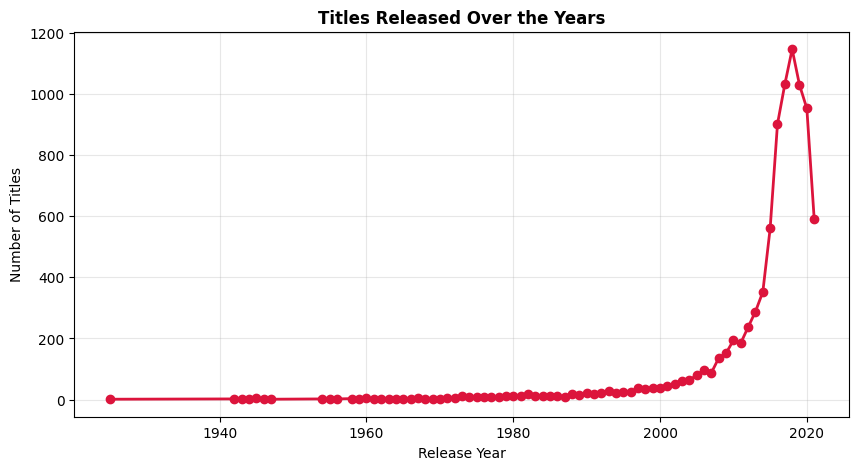

In [54]:
# Line Plot: Number of Titles Released Over the Years

year_count = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    year_count.index,
    year_count.values,
    marker="o",
    linewidth=2,
    color="crimson"
)

plt.title("Titles Released Over the Years", fontweight="bold")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)
plt.show()

In [76]:
# Tabular Format: Rating vs Content Type

pivot

type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


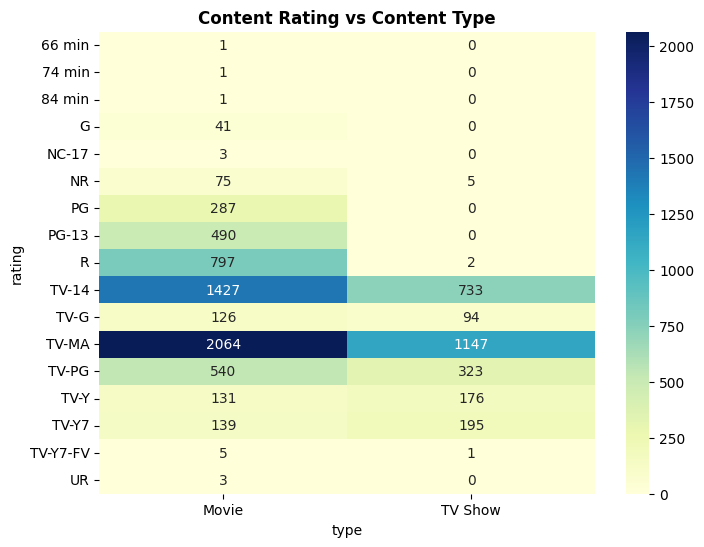

In [55]:
# Heatmap: Content Rating vs Content Type

pivot = pd.crosstab(df["rating"], df["type"])

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("Content Rating vs Content Type", fontweight="bold")

plt.show()

In [77]:
# Tabular Format: Average Duration by Rating

violin_table = (
    movies
    .groupby("rating")["duration"]
    .agg(
        Count="count",
        Minimum="min",
        Average="mean",
        Median="median",
        Maximum="max"
    )
    .round(2)
    .reset_index()
)

violin_table

,rating,Count,Minimum,Average,Median,Maximum
0,66 min,1,1,1.00,1.0,1
1,74 min,1,1,1.00,1.0,1
2,84 min,1,1,1.00,1.0,1
3,G,41,9,90.27,84.0,181
4,NC-17,3,83,125.00,112.0,180
5,NR,75,44,94.53,90.0,143
6,PG,287,13,98.28,95.0,224
7,PG-13,490,8,108.33,106.0,201
8,R,797,62,106.72,103.0,229
9,TV-14,1427,5,110.29,107.0,253


/tmp/ipykernel_645/756955225.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


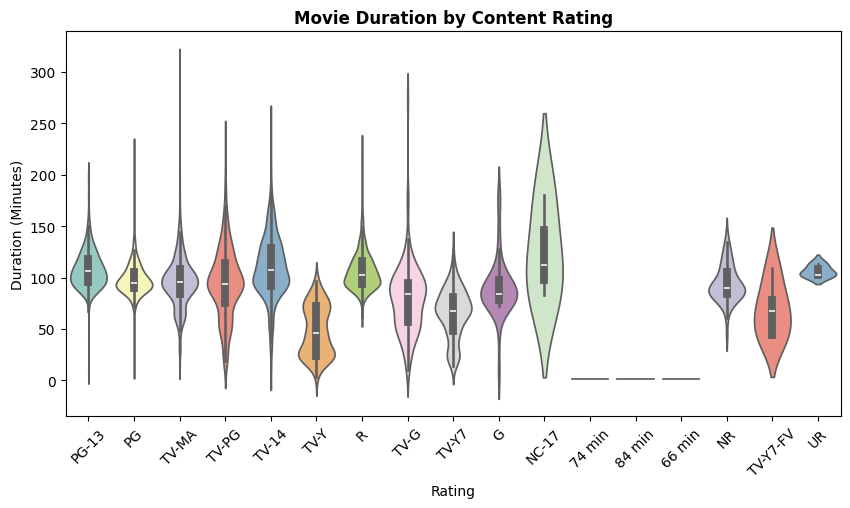

In [56]:
# Violin Plot: Movie Duration by Content Rating

plt.figure(figsize=(10,5))

sns.violinplot(
    x="rating",
    y="duration",
    data=movies,
    palette="Set3"
)

plt.xticks(rotation=45)

plt.title("Movie Duration by Content Rating", fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Duration (Minutes)")

plt.show()

In [78]:
# Tabular Format: Average Movie Duration

point_table = (
    movies
    .groupby("rating")["duration"]
    .mean()
    .round(2)
    .reset_index()
)

point_table.columns = [
    "Rating",
    "Average Duration (Minutes)"
]

point_table

,Rating,Average Duration (Minutes)
0,66 min,1.00
1,74 min,1.00
2,84 min,1.00
3,G,90.27
4,NC-17,125.00
5,NR,94.53
6,PG,98.28
7,PG-13,108.33
8,R,106.72
9,TV-14,110.29


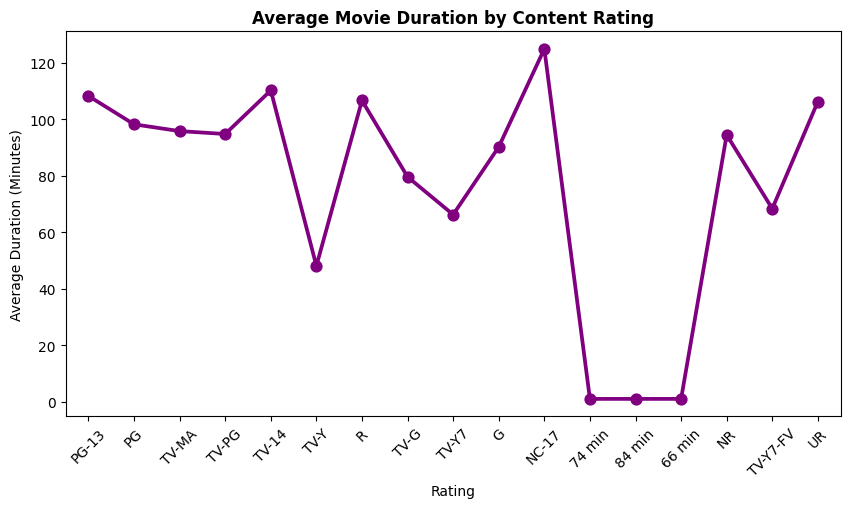

In [57]:
# Point Plot: Average Movie Duration by Content Rating

plt.figure(figsize=(10,5))

sns.pointplot(
    x="rating",
    y="duration",
    data=movies,
    errorbar=None,
    color="purple"
)

plt.xticks(rotation=45)

plt.title("Average Movie Duration by Content Rating", fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Average Duration (Minutes)")

plt.show()

In [79]:
# Tabular Format: Release Year Statistics by Content Type

strip_table = (
    df
    .groupby("type")["release_year"]
    .agg(
        Count="count",
        Minimum="min",
        Maximum="max",
        Average="mean"
    )
    .round(2)
    .reset_index()
)

strip_table

,type,Count,Minimum,Maximum,Average
0,Movie,6131,1942,2021,2013.12
1,TV Show,2676,1925,2021,2016.61


/tmp/ipykernel_645/117888685.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


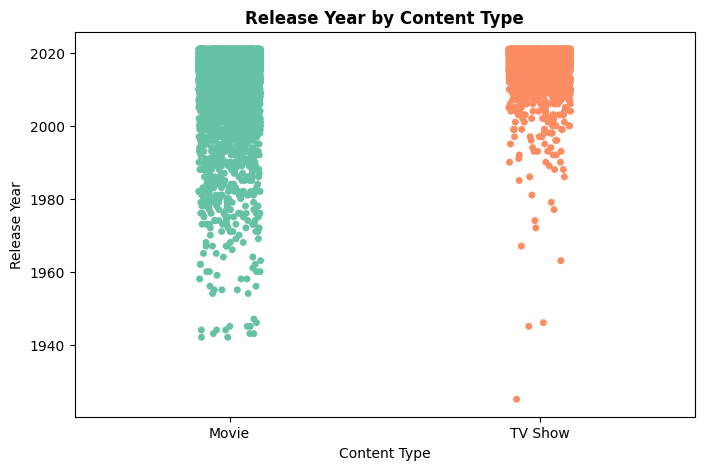

In [58]:
# Strip Plot: Release Year by Content Type

plt.figure(figsize=(8,5))

sns.stripplot(
    x="type",
    y="release_year",
    data=df,
    jitter=True,
    palette="Set2"
)

plt.title("Release Year by Content Type", fontweight="bold")
plt.xlabel("Content Type")
plt.ylabel("Release Year")

plt.show()

In [ ]:
#MULTIVARIATE ANAYSIS

In [81]:
# Tabular Format: Pair Plot Variables

pair_table = (
    movies[
        ["release_year", "duration"]
    ]
)

pair_table.head(10)

,release_year,duration
0,2020,90
6,2021,91
7,1993,125
9,2021,104
12,2021,127
13,2021,91
16,2020,67
18,2021,94
22,1996,161
23,2021,61


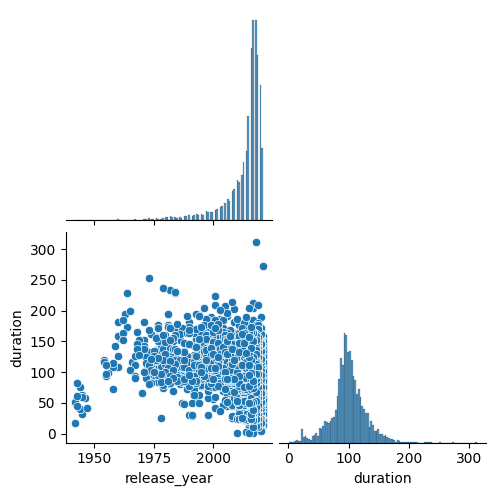

In [59]:
## Pair Plot: Relationship Between Release Year and Movie Duration
# Variables Compared: Release Year vs Movie Duration

sns.pairplot(
    movies[["release_year","duration"]],
    diag_kind="hist",
    corner=True
)

plt.show()

In [82]:
# Tabular Format: Correlation Matrix

correlation_table = (
    movies[
        ["release_year", "duration"]
    ]
    .corr()
)

correlation_table

,release_year,duration
release_year,1.000000,-0.205824
duration,-0.205824,1.000000


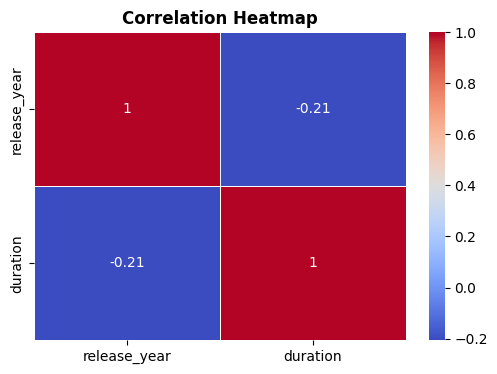

In [60]:
# Correlation Heatmap
# Variables Compared: Release Year and Movie Duration

plt.figure(figsize=(6,4))

sns.heatmap(
    movies[["release_year","duration"]].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontweight="bold")

plt.show()

In [84]:
# Tabular Format: 3D Scatter Plot Data

scatter3d_table = (
    movies[
        ["release_year", "duration", "rating"]
    ]
    .sort_values("release_year")
)

scatter3d_table.head(10)

,release_year,duration,rating
7790,1942,52,TV-14
8205,1942,18,TV-14
8660,1943,61,TV-PG
8739,1943,82,TV-PG
8763,1943,45,TV-PG
8419,1944,40,TV-PG
8436,1944,40,TV-14
8640,1944,76,TV-14
7575,1945,59,TV-MA
7219,1945,63,TV-14


In [61]:
# 3D Scatter Plot: Release Year vs Duration vs Rating

import plotly.express as px

fig = px.scatter_3d(
    movies,
    x="release_year",
    y="duration",
    z="rating",
    color="rating",
    title="3D Scatter Plot"
)

fig.show()

In [86]:
# Tabular Format: Distribution of Content by Country and Content Type

treemap_table = (
    df
    .groupby(["country", "type"])
    .size()
    .reset_index()
)

treemap_table.columns = [
    "Country",
    "Content Type",
    "Number of Titles"
]

treemap_table = treemap_table.sort_values(
    by="Number of Titles",
    ascending=False
)

treemap_table

,Country,Content Type,Number of Titles
685,United States,Movie,2498
686,United States,TV Show,1151
284,India,Movie,893
581,United Kingdom,TV Show,213
580,United Kingdom,Movie,206
...,...,...,...
15,"Argentina, Uruguay, Spain, France",Movie,1
14,"Argentina, Uruguay, Serbia",Movie,1
13,"Argentina, United States, Mexico",TV Show,1
12,"Argentina, United States",Movie,1


In [62]:
# Treemap: Distribution of Content by Country and Content Type
# Variables Compared:
# Parent -> Country
# Child -> Content Type

import plotly.express as px

fig = px.treemap(
    df,
    path=["country","type"],
    title="Treemap of Country and Content Type"
)

fig.show()

In [85]:
# Tabular Format: Bubble Chart Data

bubble_table = (
    movies[
        ["title", "release_year", "duration", "rating"]
    ]
    .sort_values("release_year")
)

bubble_table.head(10)

,title,release_year,duration,rating
7790,Prelude to War,1942,52,TV-14
8205,The Battle of Midway,1942,18,TV-14
8660,Undercover: How to Operate Behind Enemy Lines,1943,61,TV-PG
8739,Why We Fight: The Battle of Russia,1943,82,TV-PG
8763,WWII: Report from the Aleutians,1943,45,TV-PG
8419,The Memphis Belle: A Story of a\nFlying Fortress,1944,40,TV-PG
8436,The Negro Soldier,1944,40,TV-14
8640,Tunisian Victory,1944,76,TV-14
7575,Nazi Concentration Camps,1945,59,TV-MA
7219,Know Your Enemy - Japan,1945,63,TV-14


In [64]:
# Bubble Chart: Release Year vs Movie Duration (Bubble Size = Duration, Color = Rating)

import plotly.express as px

fig = px.scatter(
    movies,
    x="release_year",
    y="duration",
    size="duration",
    color="rating",
    hover_name="title",
    title="Bubble Chart: Release Year vs Movie Duration",
    size_max=25
)

fig.show()